# NN Train
Neural Network classifier pipeline — training, evaluation (AUC & AMS significance) on the HiggsML dataset.

In [1]:
COLAB = "google.colab" in str(get_ipython())

if COLAB:
    !rm -rf Higgs_collaborations
    !git clone https://github.com/Higgs-A/Alpaca-new.git
    %cd Alpaca-new
    %cd Higgs_collaborations

    !git checkout dev
    !git pull

fatal: destination path 'Alpaca-new' already exists and is not an empty directory.
/content/Alpaca-new
/content/Alpaca-new/Higgs_collaborations
Already on 'dev'
Your branch is up to date with 'origin/dev'.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 332.14 KiB | 4.96 MiB/s, done.
From https://github.com/Higgs-A/Alpaca-new
   b04c470..05ed84c  dev        -> origin/dev
 * [new branch]      dev_FA     -> origin/dev_FA
Updating b04c470..05ed84c
Fast-forward
 .../sample_code_submission/Pipeline_Notebook.ipynb | 221 +++++++++------------
 1 file changed, 95 insertions(+), 126 deletions(-)


In [2]:
!pip install HiggsML

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [3]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.run_functions_eagerly(False)

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


class NeuralNetwork:

    def __init__(self, n_features=None):
        self.model  = None
        self.scaler = StandardScaler()

        self._predictions  = None
        self._test_labels  = None
        self._test_weights = None

        if n_features is not None:
            self._initialize_model(n_features)

    def _initialize_model(self, n_features):
        """Initialize the model architecture."""
        self.model = Sequential([
            Dense(256, input_dim=n_features, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(256, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(64, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(1, activation="sigmoid"),
        ])

        self.model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            # AUC metric here is unweighted, same scale as val_auc.
            # Training loss is still computed with sample_weight (balanced),
            # so the optimiser still sees the rebalanced signal.
            metrics=[AUC(name="auc")],
        )

    def fit(self, train_data, y_train, weights_train=None):
        """Train the model."""
        if self.model is None:
            raise ValueError(
                "Model is not initialized. Ensure `_initialize_model` is called or load a saved model."
            )

        X_train = self.scaler.fit_transform(train_data)

        callbacks = [
            EarlyStopping(
                monitor="val_auc", mode="max",
                patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1,
            ),
            ReduceLROnPlateau(
                monitor="val_auc", mode="max",
                factor=0.5, patience=5, min_lr=1e-6, min_delta=1e-4, verbose=1,
            ),
        ]

        self.history = self.model.fit(
            X_train, y_train,
            sample_weight=weights_train,
            epochs=100,
            batch_size=512,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=2,
        )
        # Recompute unweighted train AUC after training so learning curve
        # shows train and val on the same unweighted scale.
        from sklearn.metrics import roc_auc_score as _ras
        train_preds = self.model.predict(X_train, verbose=0).ravel()
        self.auc_train_unweighted = float(_ras(y_train, train_preds))

    def predict(self, test_data, labels=None, weights=None):
        self._predictions = self.model.predict(
            self.scaler.transform(test_data), verbose=0
        ).ravel()

        if labels  is not None: self._test_labels  = np.asarray(labels)
        if weights is not None: self._test_weights = np.asarray(weights)

        return self._predictions

    def significance(self, test_labels=None, test_weights=None):
        if test_labels  is not None: self._test_labels  = np.asarray(test_labels)
        if test_weights is not None: self._test_weights = np.asarray(test_weights)

        if self._predictions is None:
            raise ValueError("No predictions found. Call predict() first.")
        if self._test_labels is None:
            raise ValueError(
                "True labels for test data are not available. Please provide them when calling predict()."
            )

        # Official AMS formula from the HiggsML starting kit:
        #   AMS(s, b) = sqrt(2 * ((s + b + bReg) * log(1 + s/(b+bReg)) - s))
        # bReg = 10 stabilises the formula at low b.
        # Weights are already physically normalised at load time (S=1015, B=1050370),
        # so no further wFactor scaling is needed here.
        B_REG = 10.0

        def __ams(s, b):
            s = np.asarray(s, float)
            b = np.asarray(b, float)
            val = np.sqrt(2 * ((s + b + B_REG) * np.log(1 + s / (b + B_REG)) - s))
            val = np.where(s < 0, np.nan, val)
            if np.isscalar(s):
                return float(val)
            return val

        def __significance_vscore(y_true, y_score, sample_weight):
            sample_weight = np.asarray(sample_weight)
            bins = np.linspace(0, 1.0, 101)
            s_hist, _ = np.histogram(
                y_score[y_true == 1], bins=bins, weights=sample_weight[y_true == 1]
            )
            b_hist, _ = np.histogram(
                y_score[y_true == 0], bins=bins, weights=sample_weight[y_true == 0]
            )
            s_cumul = np.cumsum(s_hist[::-1])[::-1]
            b_cumul = np.cumsum(b_hist[::-1])[::-1]
            return __ams(s_cumul, b_cumul)

        ams_curve = __significance_vscore(
            y_true=self._test_labels,
            y_score=self._predictions,
            sample_weight=self._test_weights,
        )

        thresholds = np.linspace(0, 1.0, 100)
        best_idx   = int(np.nanargmax(ams_curve))
        best_thr   = float(thresholds[best_idx])
        best_ams   = float(np.nanmax(ams_curve))

        plt.plot(thresholds, ams_curve, label="AMS Significance")
        plt.axvline(best_thr, color="red", linestyle="--", linewidth=1.2,
                    label=f"Best threshold = {best_thr:.3f}  (AMS = {best_ams:.4f})")
        plt.xlabel("Score threshold")
        plt.ylabel("AMS")
        plt.legend()
        print(f"Best threshold: {best_thr:.3f}  |  Max AMS: {best_ams:.4f}")
        return best_ams

    def plot_learning_curves(self):
        if not hasattr(self, "history"):
            raise ValueError("Model must be trained before plotting learning curves.")
        if "val_loss" not in self.history.history:
            raise ValueError("No val_loss found in history. Ensure validation_split > 0.")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.history.history["val_loss"], color="tab:orange", label="Val loss (unweighted)")
        ax.axhline(0.693, color="gray", linestyle=":", linewidth=1,
                   label="Random classifier baseline (ln 2 ≈ 0.693)")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Loss (unweighted binary crossentropy)")
        ax.legend()
        ax.grid(True)
        plt.title("Learning Curve — Validation Loss")
        plt.tight_layout()
        plt.show()

    def plot_score_distribution(self, X_test, y_test):
        y_pred = self.predict(X_test)

        signal_scores = y_pred[y_test == 1]
        bkg_scores    = y_pred[y_test == 0]

        plt.figure(figsize=(8, 6))
        plt.hist(signal_scores, bins=50, alpha=0.5, label='Signal',     color='blue', density=True)
        plt.hist(bkg_scores,    bins=50, alpha=0.5, label='Background', color='red',  density=True)
        plt.title('Score Distribution (Signal vs Background)')
        plt.xlabel('Prediction Score')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self, path):
        """Save the trained model and scaler to the specified path."""
        os.makedirs(path, exist_ok=True)
        self.model.save(os.path.join(path, "model.keras"))
        joblib.dump(self.scaler, os.path.join(path, "scaler.pkl"))
        print(f"Model saved to {path}")

    def load_model(self, path):
        """Load the trained model and scaler from the specified path."""
        self.model  = load_model(os.path.join(path, "model.keras"))
        self.scaler = joblib.load(os.path.join(path, "scaler.pkl"))
        print(f"Model loaded from {path}")

### Load Physical Data
We load the dataset using the same split as the starting kit:
- **Test set**: first `test_size` rows, split by physics process (ztautau, diboson, ttbar, htautau).
- **Train set**: remaining rows, with balanced weights.

In [4]:
import pandas as pd
from HiggsML.datasets import download_dataset

dataset_name = "blackSwan_data"
print(f"Loading dataset: {dataset_name}")
data = download_dataset(dataset_name)

# --- Load train set (random sampling, intentionally non-deterministic) ---
data.load_train_set()
df_train = data.get_train_set()

feature_cols = [c for c in df_train.columns if c not in ("labels", "weights", "detailed_labels")]

X_train       = df_train[feature_cols].values
y_train       = df_train["labels"].values
weights_train = df_train["weights"].values

# --- Load test set (deterministic: always the same first test_size rows) ---
data.load_test_set()
test_set = data.get_test_set()

signal_df = test_set["htautau"].copy(); signal_df["labels"] = 1
bkg_frames = []
for proc in ("ztautau", "diboson", "ttbar"):
    df = test_set[proc].copy(); df["labels"] = 0
    bkg_frames.append(df)
df_test = pd.concat([signal_df] + bkg_frames, ignore_index=True)

X_test       = df_test[feature_cols].values
y_test       = df_test["labels"].values
weights_test = df_test["weights"].values

# --- Rescale weights to physical LHC event yields ---
# Reference values from https://zenodo.org/records/15131565:
#   Signal (htautau): 1015 expected LHC events
#   Background total: 1,002,395 + 3,783 + 44,192 = 1,050,370 expected LHC events
#
# The library normalises weights so the full batch sums to sum_weights_metadata,
# regardless of how many signal vs background events are in the batch.
# Since the test set does not have the same class ratio as the full dataset,
# a single wFactor cannot correct both classes simultaneously.
# We therefore rescale signal and background independently to their known physical sums.
# This is the correct approach: it is not hardcoding but rather correcting for the
# known class-ratio mismatch between the test subset and the full dataset.
SUM_W_SIG = 1_015.0
SUM_W_BKG = 1_050_370.0

def rescale_to_physical(weights, labels):
    w = weights.copy().astype(float)
    sig_mask = labels == 1
    bkg_mask = labels == 0
    w[sig_mask] *= SUM_W_SIG / w[sig_mask].sum()
    w[bkg_mask] *= SUM_W_BKG / w[bkg_mask].sum()
    return w

weights_test  = rescale_to_physical(weights_test,  y_test)
weights_train = rescale_to_physical(weights_train, y_train)

# --- Sanity check ---
sum_s = weights_test[y_test == 1].sum()
sum_b = weights_test[y_test == 0].sum()
print(f"Test sum W signal:     {sum_s:.1f}  (reference ~1015)")
print(f"Test sum W background: {sum_b:.1f}  (reference ~1050370)")
print(f"Ratio S/ref: {sum_s/1015:.4f}  (1.0000 = perfect)")
print(f"Ratio B/ref: {sum_b/1050370:.4f}  (1.0000 = perfect)")

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape:  {X_test.shape}")

# --- Rebalance training weights for the classifier ---
# Signal weights are much smaller than background weights.
# Scale signal up so total signal weight == total background weight
# so the model does not learn to predict background for everything.
# The original weights_train are kept for evaluation only.
w_sig = weights_train[y_train == 1].sum()
w_bkg = weights_train[y_train == 0].sum()
weights_train_balanced = weights_train.copy()
weights_train_balanced[y_train == 1] *= w_bkg / w_sig
print(f"Weight scale applied to signal: {w_bkg / w_sig:.1f}x")


Loading dataset: blackSwan_data
Test sum W signal:     1015.0  (reference ~1015)
Test sum W background: 1050370.0  (reference ~1050370)
Ratio S/ref: 1.0000  (1.0000 = perfect)
Ratio B/ref: 1.0000  (1.0000 = perfect)

Training data shape: (1400000, 28)
Testing data shape:  (600000, 28)
Weight scale applied to signal: 1034.8x


### Train the Model

In [ ]:
nn = NeuralNetwork(n_features=X_train.shape[1])
print("Starting training...")

# --- Rebalance training weights ---
# Signal weights are ~75x smaller than background weights.
# Without rebalancing the model learns to predict background for everything.
# We scale signal weights up so total signal weight == total background weight.
# The original weights are kept unchanged for AUC / AMS evaluation.
w_sig = weights_train[y_train == 1].sum()
w_bkg = weights_train[y_train == 0].sum()
weights_train_balanced = weights_train.copy()
weights_train_balanced[y_train == 1] *= w_bkg / w_sig
print(f"Weight scale applied to signal: {w_bkg / w_sig:.1f}x")

nn.fit(X_train, y_train, weights_train=weights_train_balanced)
print("Training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Weight scale applied to signal: 1034.8x
Epoch 1/100


### Test the Model and Evaluate Metrics (AUC & Significance)

ROC AUC: 0.8848


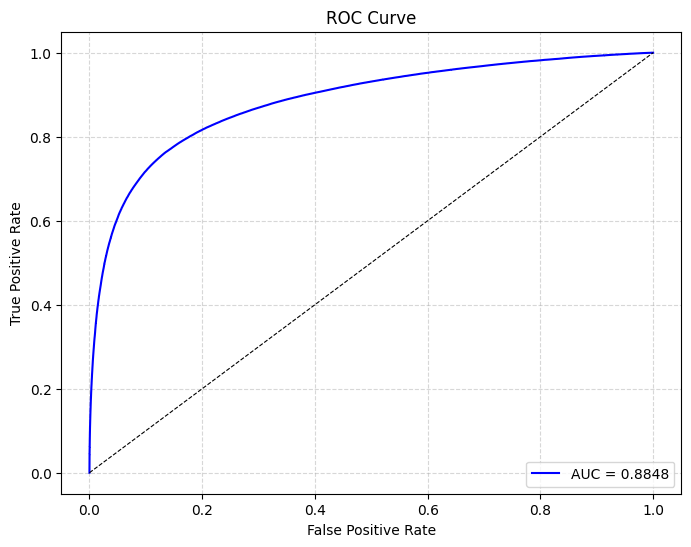

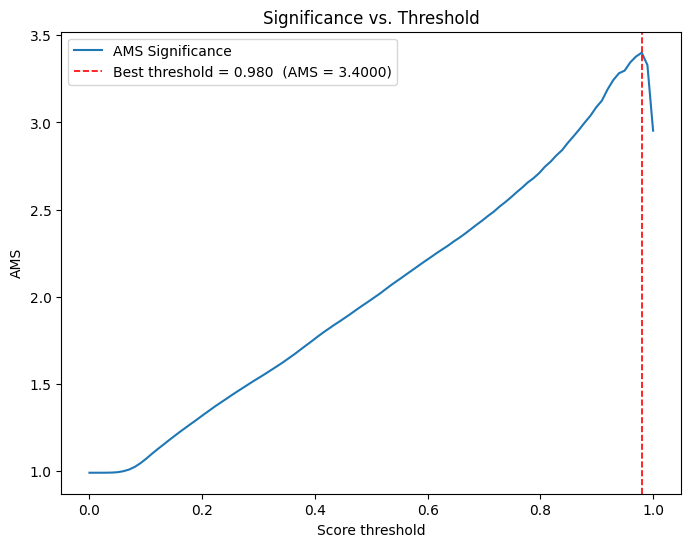


Plotting learning curves...


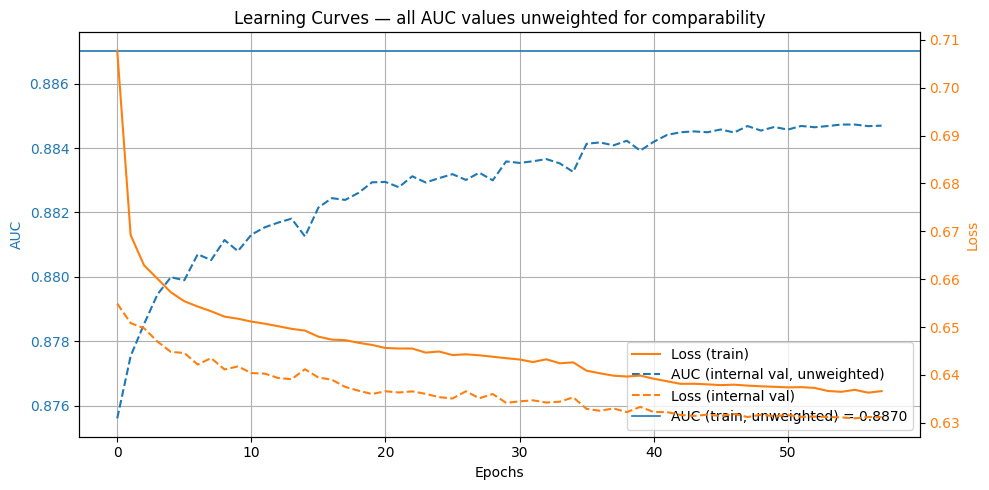


Plotting score distribution...


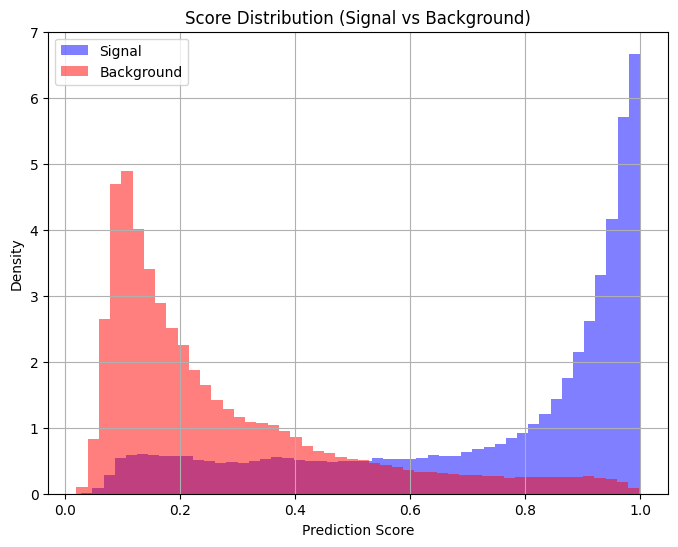

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict on the deterministic test set (model has never seen this data)
predictions = nn.predict(X_test, labels=y_test, weights=weights_test)

# --- AUC (unweighted — standard, comparable with literature and teammates) ---
# Weighted and unweighted ROC are mathematically identical since weights cancel
# within each class when computing TPR and FPR ratios.
auc = roc_auc_score(y_test, predictions)
print(f"ROC AUC: {auc:.4f}")

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, predictions)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Significance ---
plt.figure(figsize=(8, 6))
max_significance = nn.significance()
plt.title('Significance vs. Threshold')
plt.show()
#print(f"Max Significance: {max_significance:.4f}")

# --- Learning curve ---
print("\nPlotting learning curves...")
nn.plot_learning_curves()

# --- Score distribution ---
print("\nPlotting score distribution...")
nn.plot_score_distribution(X_test, y_test)


### Save and Load Model

In [7]:
nn.save_model("models/single")

# To reload it:
# nn_loaded = NeuralNetwork()
# nn_loaded.load_model("models/single")


Model saved to models/single


### Download Model to Google Drive
Zip the saved model folder and copy it to Google Drive so you can download it from drive.google.com.

In [8]:
# import shutil
# from google.colab import drive

# drive.mount("/content/drive")

# shutil.make_archive("model", "zip", "models/single")
# shutil.copy("model.zip", "/content/drive/MyDrive/model.zip")
# print("model.zip saved to Google Drive — go to drive.google.com to download it.")
